# Section 2

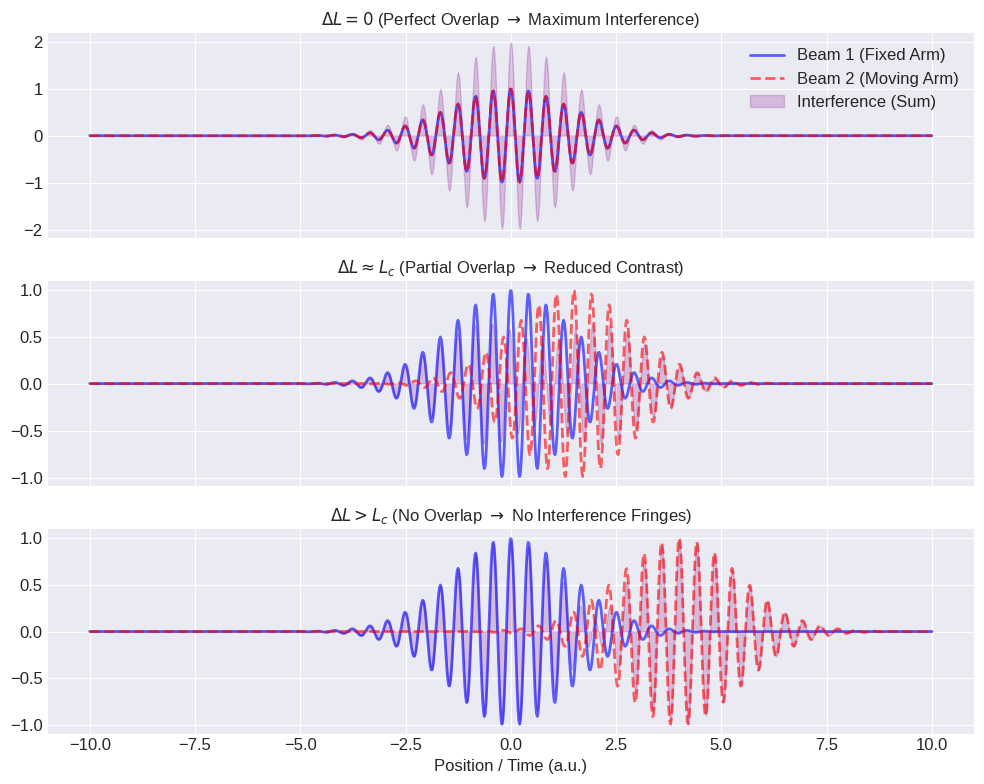

In [ ]:
"""
Simulation of Wave Packets and Temporal Coherence
Wave Packet Recombination"
"""

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

x = np.linspace(-10, 10, 1000)

def wave_packet(x, center, width):
    envelope = np.exp(-((x - center) / width)**2)
    carrier = np.cos(15 * (x - center))
    return envelope * carrier

packet_width = 2.0

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Case 1: Path difference of zero (perfect overlap of wave packets)
beam1 = wave_packet(x, center=0, width=packet_width)
beam2 = wave_packet(x, center=0, width=packet_width)
axs[0].plot(x, beam1, label='Beam 1 (Fixed Arm)', color='blue', alpha=0.6, linewidth=2)
axs[0].plot(x, beam2, label='Beam 2 (Moving Arm)', color='red', alpha=0.6, linestyle='--', linewidth=2)
axs[0].fill_between(x, beam1+beam2, color='purple', alpha=0.2, label='Interference (Sum)')
axs[0].set_title(r"$\Delta L = 0$ (Perfect Overlap $\rightarrow$ Maximum Interference)", fontsize=12)
axs[0].legend(loc='upper right')

#Case 2: Path difference on the order of coherence length (partial overlap)
shift = 1.5
beam2_shifted = wave_packet(x, center=shift, width=packet_width)
axs[1].plot(x, beam1, color='blue', alpha=0.6, linewidth=2)
axs[1].plot(x, beam2_shifted, color='red', alpha=0.6, linestyle='--', linewidth=2)
axs[1].fill_between(x, beam1+beam2_shifted, color='purple', alpha=0.2)
axs[1].set_title(rf"$\Delta L \approx L_c$ (Partial Overlap $\rightarrow$ Reduced Contrast)", fontsize=12)

# Case 3: Path difference greater than coherence length (no overlap)
shift_large = 4.0
beam2_far = wave_packet(x, center=shift_large, width=packet_width)
axs[2].plot(x, beam1, color='blue', alpha=0.6, linewidth=2)
axs[2].plot(x, beam2_far, color='red', alpha=0.6, linestyle='--', linewidth=2)
axs[2].fill_between(x, beam1+beam2_far, color='purple', alpha=0.2)
axs[2].set_title(rf"$\Delta L > L_c$ (No Overlap $\rightarrow$ No Interference Fringes)", fontsize=12)
axs[2].set_xlabel("Position / Time (a.u.)", fontsize=12)

plt.tight_layout()
plt.show()

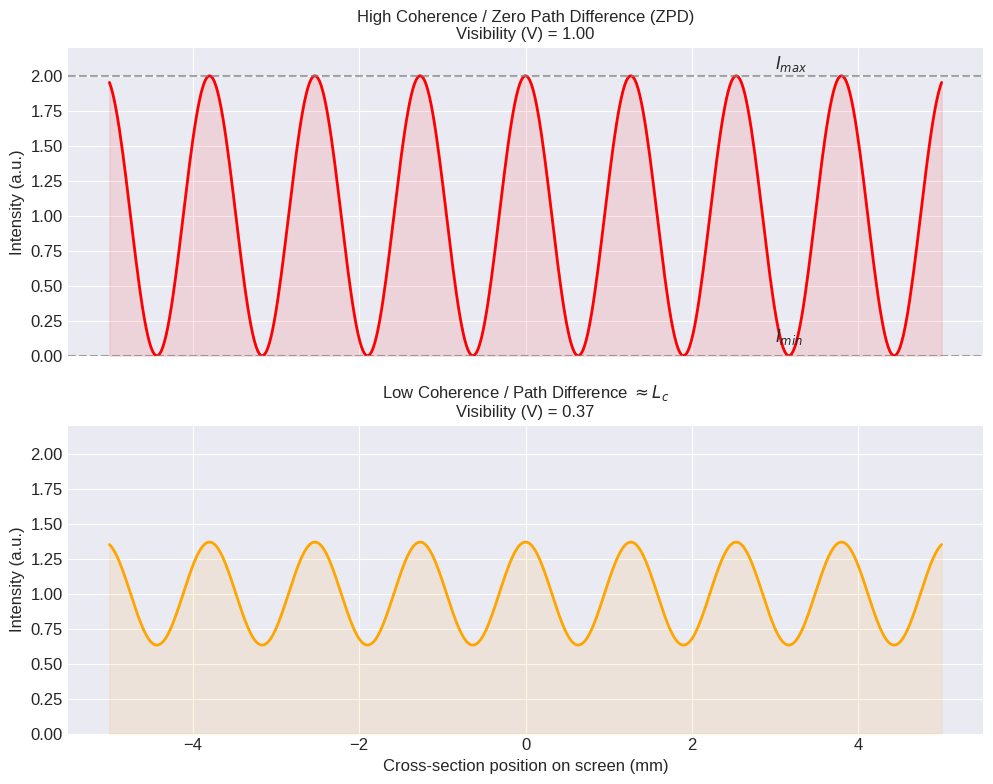

In [ ]:
# ==========================================
# Simulation of 1D intensity profile and calculation of fringe visibility
# Based on the formula: V = (I_max - I_min) / (I_max + I_min)
# ==========================================

x_axis = np.linspace(-0.005, 0.005, 500)
k_wave = 2 * np.pi / 632.8e-9

def get_1d_intensity(x, path_diff, coherence_length):
    """
    Calculate the light intensity in a 1D cross-section considering coherence loss
    """
    # Creating linear fringes (optical wedge) with a fixed angle
    tilt = 5e-4
    phase = k_wave * (x * tilt)

    visibility_factor = np.exp(-(path_diff / coherence_length)**2)

    # I = I1 + I2 + 2*sqrt(I1*I2)*V*cos(phi) -> assuming I1=I2=0.5
    intensity = 1 + visibility_factor * np.cos(phase)
    return intensity, visibility_factor

# Assume we use white light or a low-coherence source
L_c = 2e-6 # Coherence length 2 micrometers

# Case 1: Zero path difference (highest contrast)
I_high_contrast, V_high = get_1d_intensity(x_axis, path_diff=0, coherence_length=L_c)

# Case 2: Path difference equal to coherence length (contrast reduced)
I_low_contrast, V_low = get_1d_intensity(x_axis, path_diff=2e-6, coherence_length=L_c)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(x_axis * 1e3, I_high_contrast, color='red', linewidth=2)
ax1.fill_between(x_axis * 1e3, I_high_contrast, 0, color='red', alpha=0.1)
ax1.set_title(f"High Coherence / Zero Path Difference (ZPD)\nVisibility (V) = {V_high:.2f}", fontsize=12)
ax1.set_ylabel("Intensity (a.u.)")
ax1.set_ylim(0, 2.2)
ax1.axhline(2, color='gray', linestyle='--', alpha=0.7)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.7)
ax1.text(3, 2.05, "$I_{max}$", fontsize=12)
ax1.text(3, 0.1, "$I_{min}$", fontsize=12)
ax2.plot(x_axis * 1e3, I_low_contrast, color='orange', linewidth=2)
ax2.fill_between(x_axis * 1e3, I_low_contrast, 0, color='orange', alpha=0.1)
ax2.set_title(f"Low Coherence / Path Difference $\\approx L_c$\nVisibility (V) = {V_low:.2f}", fontsize=12)
ax2.set_xlabel("Cross-section position on screen (mm)", fontsize=12)
ax2.set_ylabel("Intensity (a.u.)")
ax2.set_ylim(0, 2.2)
plt.tight_layout()
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_655/700387987.py:33: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Optical Path Difference $\Delta L$ ($\mu m$)", fontsize=12)


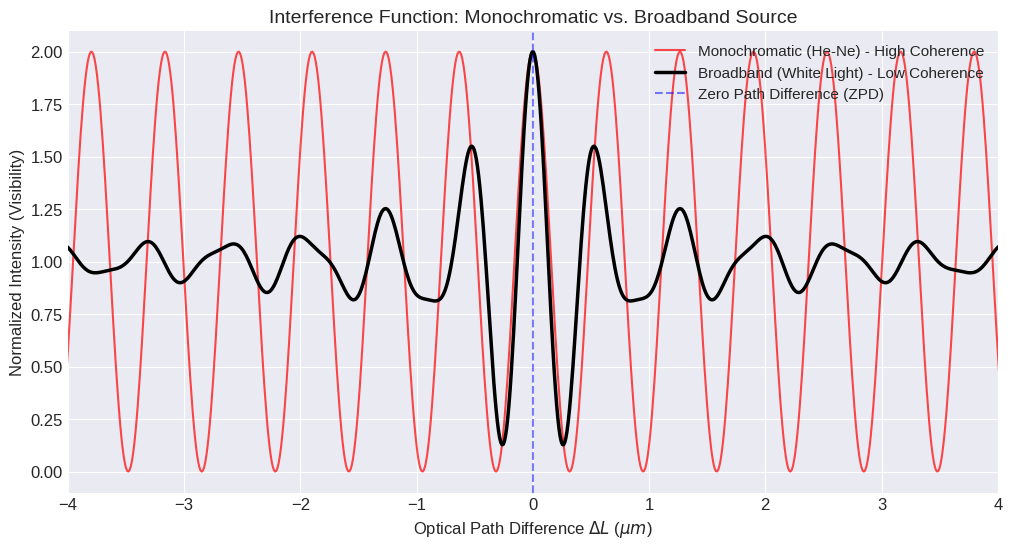

In [ ]:
# ==========================================
# Investigating the effect of coherence length on fringe visibility (Visibility)
# ==========================================

# Range of optical path difference variations (from -5 to +5 micrometers)
delta_L_range = np.linspace(-5e-6, 5e-6, 1000)

# A) Calculate the interference function for a monochromatic source (helium-neon laser)
# Due to the high coherence length, the visibility drop at this micrometer scale is negligible
lambda_HeNe = 632.8e-9
k = 2 * np.pi / lambda_HeNe
visibility_laser = 1 + np.cos(k * delta_L_range)

# B) Calculate the interference function for a broadband source (white light)
# Superposition of interference intensities of the visible spectrum (range 400 to 700 nanometers)
visible_spectrum = np.linspace(400e-9, 700e-9, 50)
visibility_white_light = np.zeros_like(delta_L_range)

for wavelength in visible_spectrum:
    k_wavelength = 2 * np.pi / wavelength
    visibility_white_light += (1 + np.cos(k_wavelength * delta_L_range))

visibility_white_light = visibility_white_light / len(visible_spectrum)

plt.figure(figsize=(12, 6))
plt.plot(delta_L_range * 1e6, visibility_laser, color='red', alpha=0.7,
         label='Monochromatic (He-Ne) - High Coherence')
plt.plot(delta_L_range * 1e6, visibility_white_light, color='black', linewidth=2.5,
         label='Broadband (White Light) - Low Coherence')

plt.axvline(x=0, color='blue', linestyle='--', alpha=0.5, label='Zero Path Difference (ZPD)')
plt.title("Interference Function: Monochromatic vs. Broadband Source", fontsize=14)
plt.xlabel("Optical Path Difference $\Delta L$ ($\mu m$)", fontsize=12)
plt.ylabel("Normalized Intensity (Visibility)", fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.xlim(-4, 4)
plt.show()

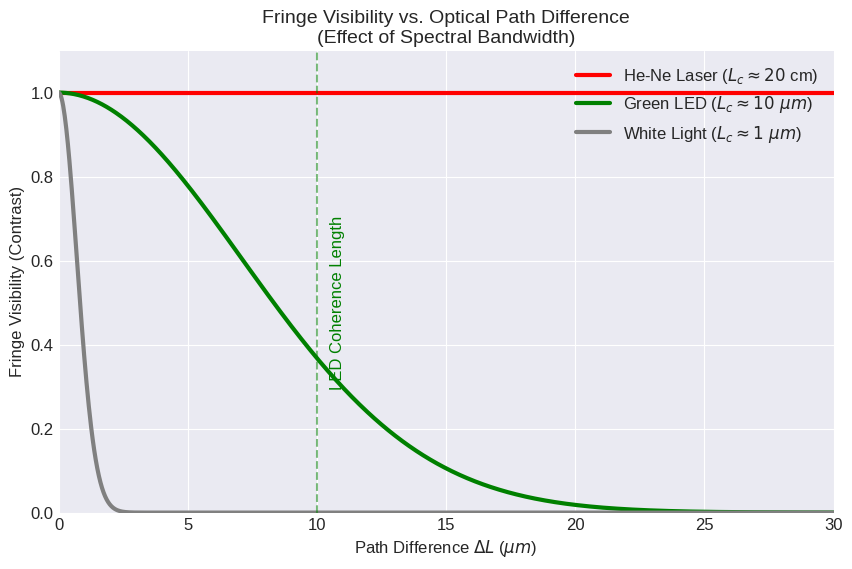

In [ ]:
# ==========================================
# Coherence Length Comparison: Laser vs LED vs White Light
# (Lc = lambda^2 / delta_lambda)
# ==========================================

delta_L = np.linspace(0, 30e-6, 1000)

def calc_visibility(path_diff, coherence_length):
    return np.exp(-(path_diff / coherence_length)**2)

Lc_HeNe = 0.20
Lc_LED = 10e-6
Lc_White = 1e-6

vis_HeNe = calc_visibility(delta_L, Lc_HeNe)
vis_LED = calc_visibility(delta_L, Lc_LED)
vis_White = calc_visibility(delta_L, Lc_White)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(delta_L * 1e6, vis_HeNe, color='red', linewidth=3, label='He-Ne Laser ($L_c \\approx 20$ cm)')
ax.plot(delta_L * 1e6, vis_LED, color='green', linewidth=3, label='Green LED ($L_c \\approx 10\\ \\mu m$)')
ax.plot(delta_L * 1e6, vis_White, color='gray', linewidth=3, label='White Light ($L_c \\approx 1\\ \\mu m$)')
ax.set_title("Fringe Visibility vs. Optical Path Difference\n(Effect of Spectral Bandwidth)", fontsize=14)
ax.set_xlabel("Path Difference $\\Delta L$ ($\\mu m$)", fontsize=12)
ax.set_ylabel("Fringe Visibility (Contrast)", fontsize=12)
ax.axvline(x=10, color='green', linestyle='--', alpha=0.5)
ax.text(10.5, 0.5, "LED Coherence Length", color='green', rotation=90, verticalalignment='center')

ax.legend(loc='upper right', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_xlim(0, 30)
plt.show()

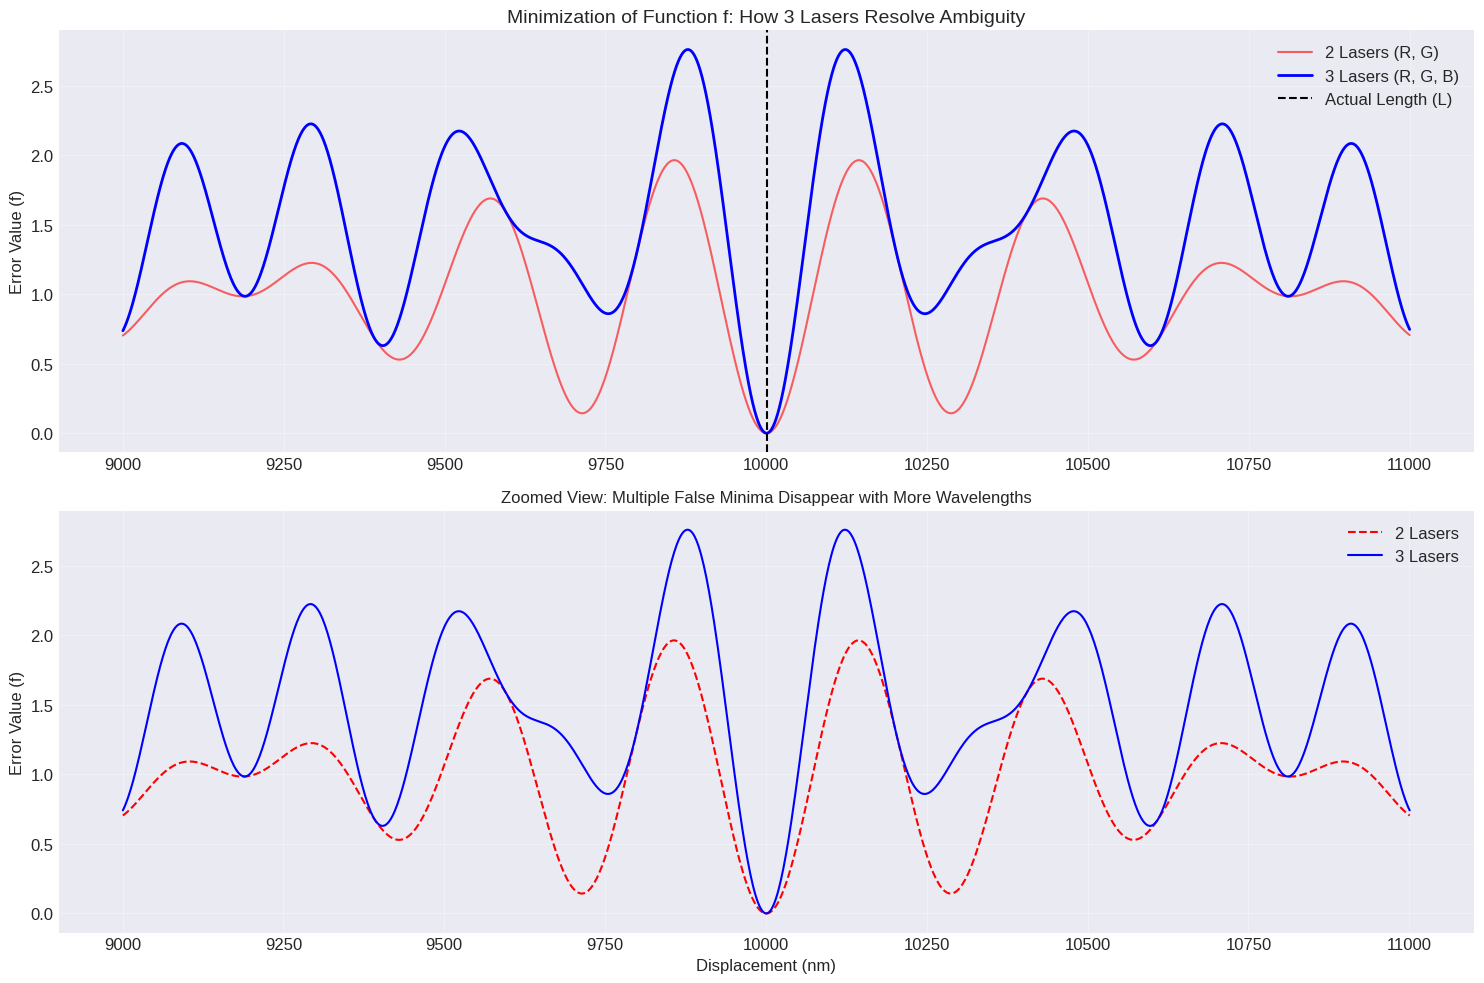

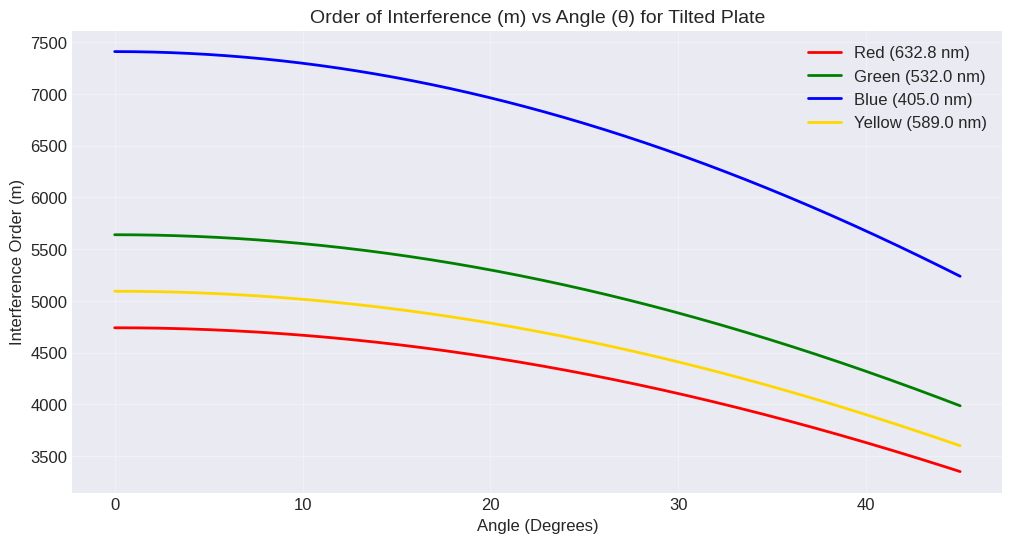

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# Multi-Wavelength Interferometry Simulation
# Comparing 2 and 3 Lasers for Absolute Length Measurement
# Based on the Minimization of Function f
# ==========================================

wavelengths = {
    'Red': 632.8,
    'Green': 532.0,
    'Blue': 405.0,
    'Yellow': 589.0,
}

light_colors = {
    'Red': 'red',
    'Green': 'green',
    'Blue': 'blue',
    'Yellow': 'gold',
}


# --- Figure 1: Ambiguity Resolution via Minimization Function f ---
def simulate_interferometry():
    L_range = np.linspace(9000, 11000, 5000)
    L_target = 10000.5
    # b = (2L / lambda) mod 1
    fractions = {
        color: (2 * L_target / wave) % 1 for color, wave in wavelengths.items()
    }
    # f = sum( [ sin(pi * ((2L/lambda) mod 1 - measured_b)) ]^2 )
    def get_cost(L, selected_waves):
        cost = 0
        for color in selected_waves:
            wave = wavelengths[color]
            b_measured = fractions[color]
            b_calc = (2 * L / wave) % 1
            cost += np.sin(np.pi * (b_calc - b_measured)) ** 2
        return cost

    f_2_lasers = get_cost(L_range, ['Red', 'Green'])
    f_3_lasers = get_cost(L_range, ['Red', 'Green', 'Blue'])

    plt.figure(figsize=(15, 10))
    plt.subplot(2, 1, 1)
    plt.plot(L_range, f_2_lasers, 'r-', alpha=0.6, label='2 Lasers (R, G)')
    plt.plot(L_range, f_3_lasers, 'b-', linewidth=2, label='3 Lasers (R, G, B)')
    plt.axvline(
        L_target, color='black', linestyle='--', label='Actual Length (L)'
    )
    plt.title(
        'Minimization of Function f: How 3 Lasers Resolve Ambiguity', fontsize=14
    )
    plt.ylabel('Error Value (f)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    zoom_range = np.linspace(L_target - 1000, L_target + 1000, 1000)
    plt.plot(
        zoom_range,
        get_cost(zoom_range, ['Red', 'Green']),
        'r--',
        label='2 Lasers',
    )
    plt.plot(
        zoom_range,
        get_cost(zoom_range, ['Red', 'Green', 'Blue']),
        'b-',
        label='3 Lasers',
    )
    plt.title(
        'Zoomed View: Multiple False Minima Disappear with More Wavelengths',
        fontsize=12,
    )
    plt.xlabel('Displacement (nm)', fontsize=12)
    plt.ylabel('Error Value (f)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# --- Figure 2: Interference Order (m) vs Angle (theta) ---
def plot_m_vs_theta():
    theta = np.linspace(0, np.pi / 4, 500)
    n = 1.5
    e = 1e6  # Thickness: 1 mm (expressed in nanometers)

    plt.figure(figsize=(12, 6))
    for color, wave in wavelengths.items():
        # m = (2 * n * e * cos(theta)) / lambda
        m = (2 * n * e * np.cos(theta)) / wave
        plt.plot(
            np.degrees(theta),
            m,
            color=light_colors[color],
            linewidth=2,
            label=f'{color} ({wave} nm)',
        )

    plt.title(
        'Order of Interference (m) vs Angle (θ) for Tilted Plate', fontsize=14
    )
    plt.xlabel('Angle (Degrees)', fontsize=12)
    plt.ylabel('Interference Order (m)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

simulate_interferometry()
plot_m_vs_theta()

Simulation complete. Plot saved as 'Theoretical_Simulation_Ambiguity.png'.


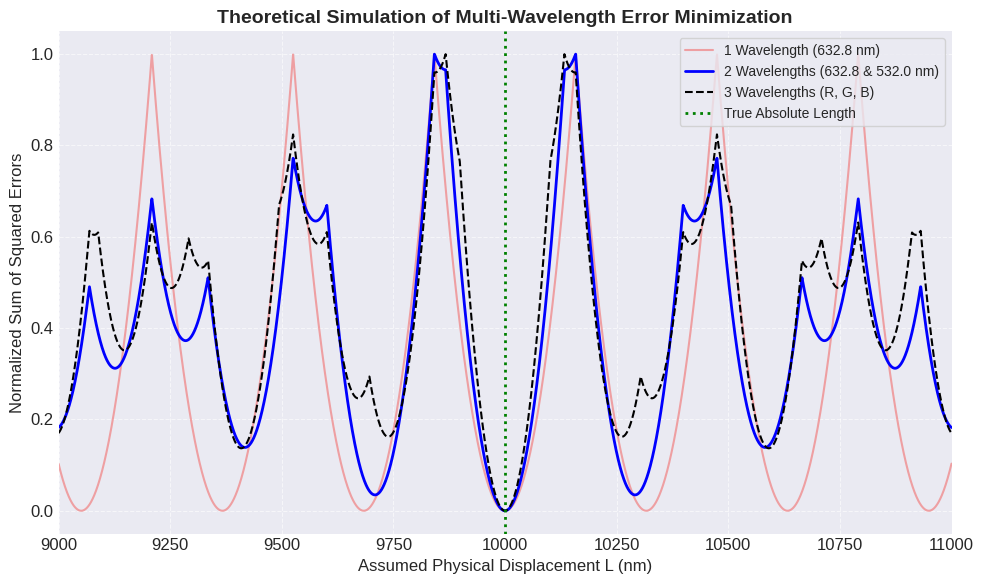

In [ ]:
"""
Theoretical Simulation of Multi-Wavelength Interferometry
for Resolving Fringe-Order Ambiguity.

This script simulates the least-squares error function for single,
dual, and three-wavelength interferometry to demonstrate the
synthetic wavelength (beating) effect.
"""

import numpy as np
import matplotlib.pyplot as plt

def simulate_interferometry():
    #  Input Parameters: Laser Wavelengths in nanometers (nm)
    lambda_R = 632.8
    lambda_G = 532.0
    lambda_B = 405.0

    # We assume a hypothetical absolute thickness of 10,000 nm (10 micrometers)
    L_true = 10000.0

    #  Simulate the measured fractional fringe displacements (b)
    b_R = (2 * L_true / lambda_R) % 1.0
    b_G = (2 * L_true / lambda_G) % 1.0
    b_B = (2 * L_true / lambda_B) % 1.0

    # Generate a sweep of test lengths around the true value
    L_test = np.linspace(9000, 11000, 5000)

    error_1W = np.zeros_like(L_test)
    error_2W = np.zeros_like(L_test)
    error_3W = np.zeros_like(L_test)

    # Calculate the Least-Squares Error for each test length
    for idx, L in enumerate(L_test):
        N_R = round((2 * L / lambda_R) - b_R)
        N_G = round((2 * L / lambda_G) - b_G)
        N_B = round((2 * L / lambda_B) - b_B)

        err_R = (2 * L - (N_R + b_R) * lambda_R)**2
        err_G = (2 * L - (N_G + b_G) * lambda_G)**2
        err_B = (2 * L - (N_B + b_B) * lambda_B)**2

        error_1W[idx] = err_R
        error_2W[idx] = err_R + err_G
        error_3W[idx] = err_R + err_G + err_B

    # Normalize the error functions for clear visual comparison [0, 1]
    error_1W = error_1W / np.max(error_1W)
    error_2W = error_2W / np.max(error_2W)
    error_3W = error_3W / np.max(error_3W)

    plt.figure(figsize=(10, 6))
    plt.plot(L_test, error_1W, color='lightcoral', linestyle='-', alpha=0.7,
             label=f'1 Wavelength ({lambda_R} nm)')
    plt.plot(L_test, error_2W, color='blue', linewidth=2,
             label=f'2 Wavelengths ({lambda_R} & {lambda_G} nm)')
    plt.plot(L_test, error_3W, color='black', linestyle='--', linewidth=1.5,
             label='3 Wavelengths (R, G, B)')
    plt.axvline(x=L_true, color='green', linestyle=':', linewidth=2,
                label='True Absolute Length')
    plt.title('Theoretical Simulation of Multi-Wavelength Error Minimization',
              fontsize=14, fontweight='bold')
    plt.xlabel('Assumed Physical Displacement L (nm)', fontsize=12)
    plt.ylabel('Normalized Sum of Squared Errors', fontsize=12)
    plt.xlim([9000, 11000])
    plt.ylim([-0.05, 1.05])
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, fontsize=10)
    plt.tight_layout()
    plt.savefig('Theoretical_Simulation_Ambiguity.png', dpi=300)
    print("Simulation complete. Plot saved as 'Theoretical_Simulation_Ambiguity.png'.")
    plt.show()

if __name__ == "__main__":
    simulate_interferometry()

#Section 3

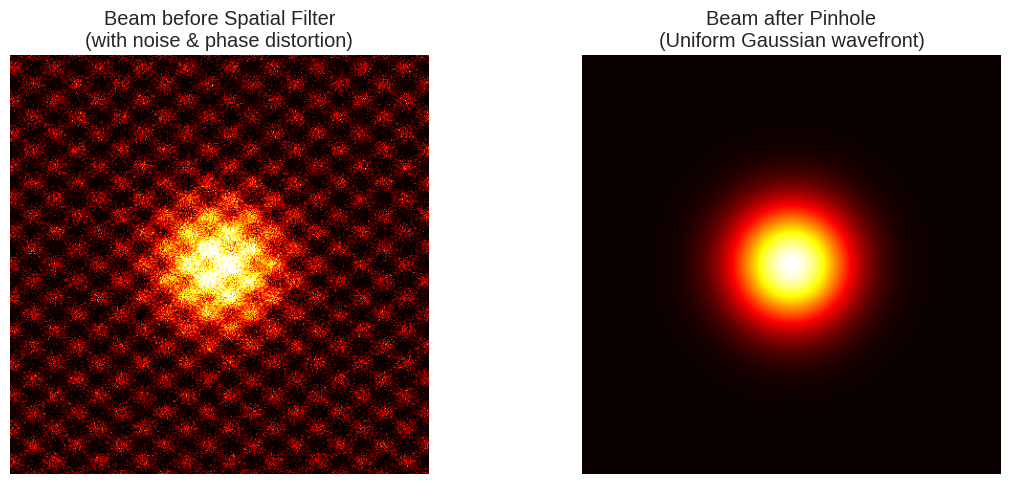

In [ ]:
# ==========================================
# Simulation of spatial filter (pinhole) performance
# ==========================================

x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# Model the ideal beam with a Gaussian intensity distribution
ideal_beam = np.exp(-(R**2) / 8)

# Add random noise and high-frequency fluctuations for simulation
noise = np.random.normal(0, 0.15, ideal_beam.shape)
high_freq_noise = np.sin(3*X) * np.cos(4*Y) * 0.2
noisy_beam = ideal_beam + noise + high_freq_noise
noisy_beam = np.clip(noisy_beam, 0, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax1.imshow(noisy_beam, cmap='hot', extent=[-10, 10, -10, 10])
ax1.set_title("Beam before Spatial Filter\n(with noise & phase distortion)")
ax1.axis('off')
im2 = ax2.imshow(ideal_beam, cmap='hot', extent=[-10, 10, -10, 10])
ax2.set_title("Beam after Pinhole\n(Uniform Gaussian wavefront)")
ax2.axis('off')
plt.tight_layout()
plt.show()

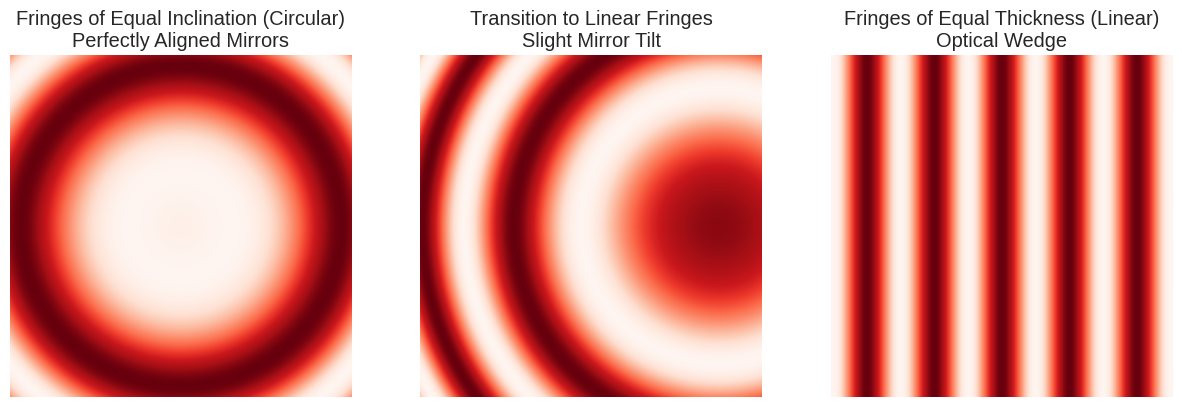

In [ ]:
# ==========================================
# Geometric modeling of Michelson interference patterns
# ==========================================

lambda_HeNe = 632.8e-9
k = 2 * np.pi / lambda_HeNe
x_screen = np.linspace(-0.01, 0.01, 500)
y_screen = np.linspace(-0.01, 0.01, 500)
X_scr, Y_scr = np.meshgrid(x_screen, y_screen)
R_scr_sq = X_scr**2 + Y_scr**2

def calculate_interference_pattern(delta_L, tilt_angle_x=0):
    """
    Calculate the light intensity distribution on the screen based on path length difference and mirror angle
    delta_L: Optical path difference of the arms
    tilt_angle_x: Mirror tilt angle relative to the optical axis
    """
    f = 0.5 # Effective focal length to the screen

    phase_spherical = k * delta_L * (1 - R_scr_sq / (2 * f**2))
    phase_tilt = k * (X_scr * tilt_angle_x * 2)
    total_phase = phase_spherical + phase_tilt
    Intensity = 1 + np.cos(total_phase)
    return Intensity

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Case 1: Perfectly parallel mirrors (Fringes of Equal Inclination)
I_circular = calculate_interference_pattern(delta_L=0.002, tilt_angle_x=0)
axs[0].imshow(I_circular, cmap='Reds', extent=[-1, 1, -1, 1])
axs[0].set_title("Fringes of Equal Inclination (Circular)\nPerfectly Aligned Mirrors")

# Case 2: Slight mirror tilt
I_mixed = calculate_interference_pattern(delta_L=0.002, tilt_angle_x=3e-5)
axs[1].imshow(I_mixed, cmap='Reds', extent=[-1, 1, -1, 1])
axs[1].set_title("Transition to Linear Fringes\nSlight Mirror Tilt")

# Case 3: Formation of optical wedge (Fringes of Equal Thickness)
I_linear = calculate_interference_pattern(delta_L=0, tilt_angle_x=8e-5)
axs[2].imshow(I_linear, cmap='Reds', extent=[-1, 1, -1, 1])
axs[2].set_title("Fringes of Equal Thickness (Linear)\nOptical Wedge")

for ax in axs:
    ax.axis('off')
plt.show()

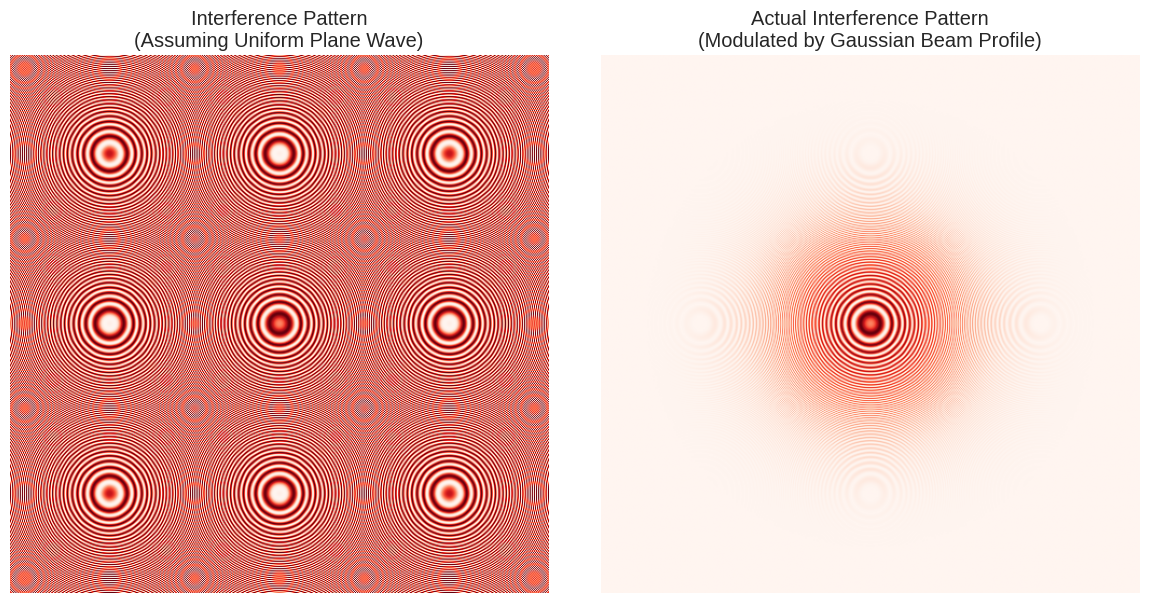

In [ ]:
# ==========================================
# Simulation of the effect of Gaussian beam distribution on the interference pattern
#  Effect of Gaussian distribution on fringe observation
# ==========================================

x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)
X, Y = np.meshgrid(x, y)
R_sq = X**2 + Y**2

# Model the laser beam intensity envelope (Gaussian distribution)
w0 = 2.5 # w0 is the beam radius
gaussian_envelope = np.exp(-2 * R_sq / w0**2)

# Model the interference phase (concentric rings due to radial path difference)
k = 2 * np.pi / (632.8e-9)
d = 1e-3 # Path difference of one millimeter
f = 10 # Distance to the screen
phase_interference = k * d * (1 - R_sq / (2 * f**2))
intensity_pure = 1 + np.cos(phase_interference)
intensity_final = gaussian_envelope * intensity_pure

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(intensity_pure, cmap='Reds', extent=[-5, 5, -5, 5])
ax1.set_title("Interference Pattern\n(Assuming Uniform Plane Wave)")
ax1.axis('off')
ax2.imshow(intensity_final, cmap='Reds', extent=[-5, 5, -5, 5])
ax2.set_title("Actual Interference Pattern\n(Modulated by Gaussian Beam Profile)")
ax2.axis('off')
plt.tight_layout()
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_655/1040553450.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Mirror Displacement ($\mu m$)", fontsize=12)


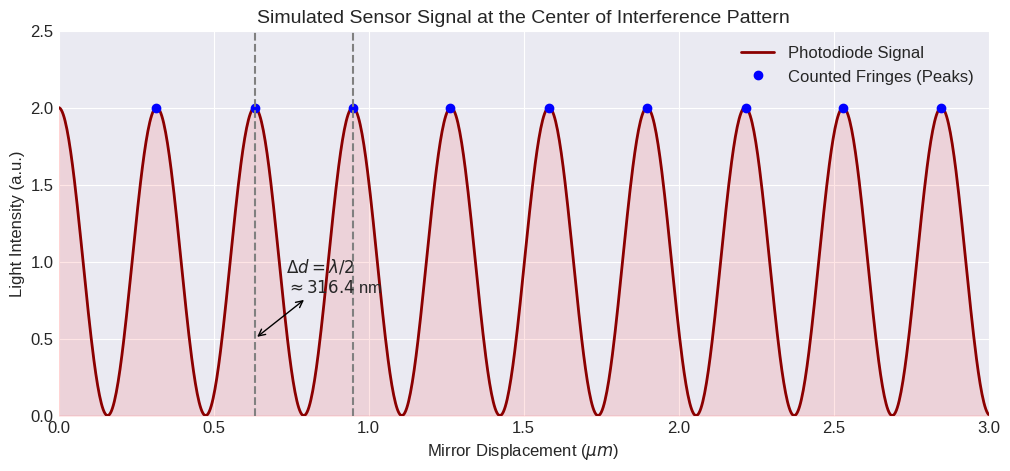

In [ ]:
# ==========================================
# Simulation of optical signal recording by a sensor (photodiode) at the center of the interference pattern
# Modeling the fringe counting process during continuous mirror displacement
# ==========================================

mirror_displacement_um = np.linspace(0, 3, 1000)
lambda_nm = 632.8
k_val = 2 * np.pi / (lambda_nm * 1e-3)
# I = I0(1 + cos(k * 2d)) -> path difference equals 2d
sensor_intensity = 1 + np.cos(k_val * 2 * mirror_displacement_um)

plt.figure(figsize=(12, 5))
plt.plot(mirror_displacement_um, sensor_intensity, color='darkred', linewidth=2, label='Photodiode Signal')
plt.fill_between(mirror_displacement_um, sensor_intensity, 0, color='red', alpha=0.1)
from scipy.signal import find_peaks
peaks, _ = find_peaks(sensor_intensity)
plt.plot(mirror_displacement_um[peaks], sensor_intensity[peaks], 'bo', label='Counted Fringes (Peaks)')
plt.title("Simulated Sensor Signal at the Center of Interference Pattern", fontsize=14)
plt.xlabel("Mirror Displacement ($\mu m$)", fontsize=12)
plt.ylabel("Light Intensity (a.u.)", fontsize=12)

fringe_spacing = lambda_nm / 2 / 1000 # in micrometers
plt.axvline(x=mirror_displacement_um[peaks[1]], color='gray', linestyle='--')
plt.axvline(x=mirror_displacement_um[peaks[2]], color='gray', linestyle='--')
plt.annotate(f'$\\Delta d = \\lambda / 2$\n$\\approx {fringe_spacing*1000:.1f}$ nm',
             xy=(mirror_displacement_um[peaks[1]], 0.5),
             xytext=(mirror_displacement_um[peaks[1]] + 0.1, 0.8),
             arrowprops=dict(facecolor='black', arrowstyle='<->'), fontsize=12)

plt.legend(loc='upper right', fontsize=12)
plt.xlim(0, 3)
plt.ylim(0, 2.5)
plt.show()

#Section 4

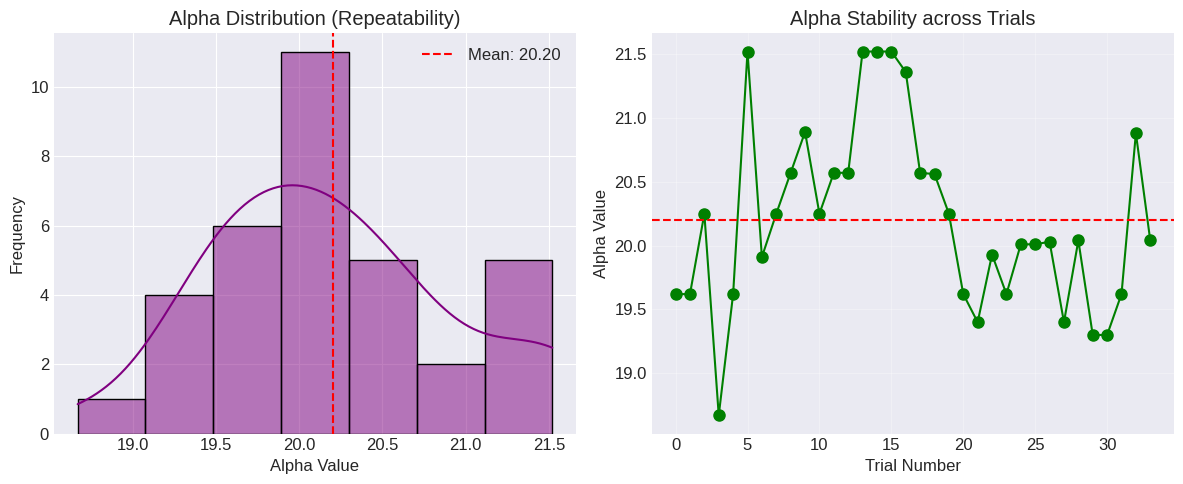

In [ ]:
import seaborn as sns

alpha_values = [19.62,19.62,20.25,18.67,19.62,21.52,19.91,20.25,20.57,20.89,20.25,20.57,20.57,21.52,21.52,21.52,21.36,20.57,20.56,20.25,19.62,19.40,19.93,19.62,20.01,20.01,20.03,19.40,20.04,19.30,19.30,19.62,20.88,20.04]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(alpha_values, kde=True, color='purple')
plt.axvline(np.mean(alpha_values), color='red', linestyle='--', label=f'Mean: {np.mean(alpha_values):.2f}')
plt.title('Alpha Distribution (Repeatability)')
plt.xlabel('Alpha Value')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(alpha_values, 'o-', color='green', markersize=8)
plt.axhline(np.mean(alpha_values), color='red', linestyle='--')
plt.title('Alpha Stability across Trials')
plt.xlabel('Trial Number')
plt.ylabel('Alpha Value')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_655/2223769057.py:37: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Mirror Displacement $d$ ($\mu m$)", fontsize=12)


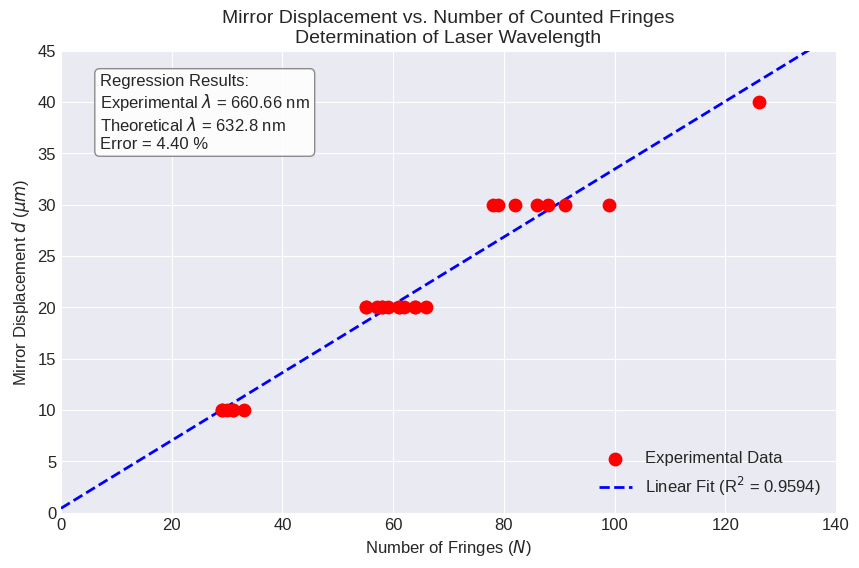

In [ ]:
# ==========================================
# Analysis of experimental data from the fringe counting experiment
# Calculation of laser wavelength using linear fitting (regression)
# ==========================================
from scipy.stats import linregress

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

d_raw = np.array([1, 2, 3, 4, 3, 3, 2, 2,2, 1, 2,2, 1,1,2, 3,3,2,3,3,2,1,1,2,2,2]) # Mirror displacement
N_fringes = np.array([29, 66,82, 126, 79, 86, 64, 61,62, 29, 58,58,33,30,55, 78,88,64,91,99,61,31,31,55,57,59])

# Convert displacement to meters (multiply by 10 micrometers)
d_meters = d_raw * 10e-6

# Relation: lambda = 2d / N
lambda_calculated_nm = (2 * d_meters / N_fringes) * 1e9

# ==========================================
# Perform linear regression to find the best wavelength value
# Formula: d = (lambda / 2) * N -> the slope of the line equals (lambda / 2)
# ==========================================
slope, intercept, r_value, p_value, std_err = linregress(N_fringes, d_meters)

lambda_regression_nm = (slope * 2) * 1e9
lambda_theoretical = 632.8 # Nominal wavelength of helium-neon laser

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(N_fringes, d_meters * 1e6, color='red', s=80, label='Experimental Data', zorder=5)
N_line = np.linspace(0, 140, 100)
d_line = slope * N_line + intercept
ax.plot(N_line, d_line * 1e6, color='blue', linestyle='--', linewidth=2,
        label=f'Linear Fit (R$^2$ = {r_value**2:.4f})')
ax.set_title("Mirror Displacement vs. Number of Counted Fringes\nDetermination of Laser Wavelength", fontsize=14)
ax.set_xlabel("Number of Fringes ($N$)", fontsize=12)
ax.set_ylabel("Mirror Displacement $d$ ($\mu m$)", fontsize=12)
text_str = (f"Regression Results:\n"
            f"Experimental $\\lambda$ = {lambda_regression_nm:.2f} nm\n"
            f"Theoretical $\\lambda$ = {lambda_theoretical} nm\n"
            f"Error = {abs(lambda_regression_nm - lambda_theoretical)/lambda_theoretical * 100:.2f} %")
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax.legend(loc='lower right', fontsize=12)
plt.xlim(0, 140)
plt.ylim(0, 45)
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_655/559717260.py:38: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Calculated Lamella Thickness ($\mu m$)', fontsize=12)


Plot saved as 'Single_Wavelength_Scatter.png'


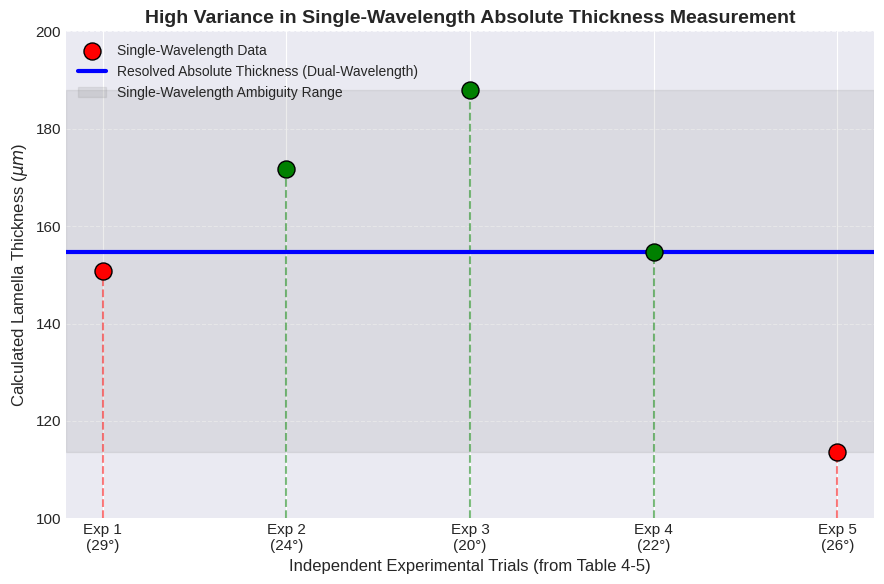

In [ ]:
"""
Comparison of Single-Wavelength Ambiguity vs. Dual-Wavelength Stability
This script uses the exact experimental data from Table 4-5 to visually
demonstrate the massive variance in single-wavelength thickness calculations.
"""

import matplotlib.pyplot as plt
import numpy as np

def plot_ambiguity_scatter():

    experiments = ['Exp 1\n(29°)', 'Exp 2\n(24°)', 'Exp 3\n(20°)', 'Exp 4\n(22°)', 'Exp 5\n(26°)']
    thicknesses = [150.7, 171.7, 188.0, 154.6, 113.6] #(um)
    laser_colors = ['red', 'green', 'green', 'green', 'red']
    x_positions = np.arange(len(experiments))

    plt.figure(figsize=(9, 6))
    for i in range(len(experiments)):
        plt.scatter(x_positions[i], thicknesses[i], color=laser_colors[i],
                    s=150, zorder=3, edgecolors='black',
                    label='Single-Wavelength Data' if i==0 else "")

        plt.vlines(x_positions[i], ymin=100, ymax=thicknesses[i],
                   colors=laser_colors[i], linestyles='dashed', alpha=0.5)


    true_thickness_estimate = 154.6

    plt.axhline(y=true_thickness_estimate, color='blue', linewidth=3,
                label='Resolved Absolute Thickness (Dual-Wavelength)')

    plt.axhspan(min(thicknesses), max(thicknesses), color='gray', alpha=0.15,
                label='Single-Wavelength Ambiguity Range')

    plt.xticks(x_positions, experiments, fontsize=11)
    plt.yticks(fontsize=11)
    plt.title('High Variance in Single-Wavelength Absolute Thickness Measurement', fontsize=14, fontweight='bold')
    plt.ylabel('Calculated Lamella Thickness ($\mu m$)', fontsize=12)
    plt.xlabel('Independent Experimental Trials (from Table 4-5)', fontsize=12)
    plt.ylim([100, 200])

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Single_Wavelength_Scatter.png', dpi=300)
    print("Plot saved as 'Single_Wavelength_Scatter.png'")
    plt.show()

if __name__ == "__main__":
    plot_ambiguity_scatter()

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, correlate
from scipy.ndimage import gaussian_filter1d


try:
    import rawpy
    HAS_RAWPY = True
except ImportError:
    HAS_RAWPY = False
    import cv2


def load_image(file_path):
    """
    Read CR2 raw image or common formats (JPG, PNG, TIFF)
    """
    if file_path.lower().endswith('.cr2') and HAS_RAWPY:
        with rawpy.imread(file_path) as raw:
            rgb = raw.postprocess()
            return rgb
    else:
        bgr = cv2.imread(file_path)
        if bgr is None:
            raise FileNotFoundError(f"File not found: {file_path}")
        return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def extract_fractional_b(image, laser_color='Red', split_ratio=0.5, debug_plot=False, img_name=""):
    """
    Calculate the fractional value b = Delta_i / i
    - laser_color: select the more optimal color channel ('Red' or 'Green')
    """
    if laser_color.lower() == 'red':
        channel = image[:, :, 0].astype(float)
    elif laser_color.lower() == 'green':
        channel = image[:, :, 1].astype(float)
    else:
        channel = np.mean(image, axis=2).astype(float)

    h, w = channel.shape

    # Define the upper region (reference) and lower region (location of lamella shift in image 5226)
    # Image margins (10% top and bottom) are removed to eliminate frame distortions
    split_y = int(h * split_ratio)
    y_start = int(h * 0.1)
    y_end = int(h * 0.9)

    top_region = channel[y_start:split_y, :]
    bottom_region = channel[split_y:y_end, :]

    # Column averaging in each region to greatly reduce noise
    profile_top = np.mean(top_region, axis=0)
    profile_bottom = np.mean(bottom_region, axis=0)

    # Normalization and gentle Gaussian filter to smooth edges
    sigma = 3.0
    sig_top = gaussian_filter1d(profile_top - np.mean(profile_top), sigma=sigma)
    sig_bot = gaussian_filter1d(profile_bottom - np.mean(profile_bottom), sigma=sigma)

    # Calculate the average fringe period (i) based on peaks of the reference profile
    peaks, _ = find_peaks(sig_top, distance=15, prominence=np.std(sig_top) * 0.5)
    if len(peaks) < 2:
        # If not detected, test on the bottom region
        peaks, _ = find_peaks(sig_bot, distance=15, prominence=np.std(sig_bot) * 0.5)

    if len(peaks) >= 2:
        fringe_spacing_i = np.mean(np.diff(peaks))
    else:
        # If the number of peaks is low, Fourier transform is used to estimate the period
        fft_vals = np.abs(np.fft.rfft(sig_top))
        dominant_freq = np.argmax(fft_vals[1:]) + 1
        fringe_spacing_i = len(sig_top) / dominant_freq

    # Calculate the precise sub-pixel shift (Delta_i) with Cross-Correlation
    # This method ensures that very small shifts in image 5226 do not become zero
    corr = correlate(sig_bot, sig_top, mode='same')
    lags = np.arange(-len(sig_top) // 2, len(sig_top) // 2)

    # Limit the correlation search range to one period around the center
    search_radius = int(fringe_spacing_i)
    center_idx = len(corr) // 2
    local_window = slice(center_idx - search_radius, center_idx + search_radius + 1)

    sub_corr = corr[local_window]
    sub_lags = lags[local_window]

    max_idx = np.argmax(sub_corr)

    # Parabolic interpolation to achieve sub-pixel accuracy
    if 0 < max_idx < len(sub_corr) - 1:
        y0 = sub_corr[max_idx - 1]
        y1 = sub_corr[max_idx]
        y2 = sub_corr[max_idx + 1]

        # Sub-pixel correction formula for the parabola vertex
        delta_sub = (y0 - y2) / (2.0 * (y0 - 2.0 * y1 + y2 + 1e-12))
        delta_i = sub_lags[max_idx] + delta_sub
    else:
        delta_i = float(sub_lags[max_idx])

    # Calculate the fractional order b
    # b must be a positive number between 0 and 1
    shift_in_fringes = delta_i / fringe_spacing_i
    b = shift_in_fringes % 1.0

    #  plotting to check performance and match image 5226
    if debug_plot:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(sig_top, 'b-', label='Top Profile (Ref)')
        plt.plot(sig_bot, 'r--', label='Bottom Profile (Shifted)')
        plt.title(f"{img_name}\nFringe Spacing (i) = {fringe_spacing_i:.2f} px")
        plt.xlabel('Horizontal Pixel Position')
        plt.ylabel('Intensity (Filtered)')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(sub_lags, sub_corr, 'k.-')
        plt.axvline(x=delta_i, color='green', linestyle='--', label=f'Peak Shift = {delta_i:.3f} px')
        plt.title(f"Sub-pixel Shift\nDelta_i = {delta_i:.3f} px  -->  b = {b:.4f}")
        plt.xlabel('Lag (Pixels)')
        plt.ylabel('Correlation')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return b, fringe_spacing_i, delta_i


# ==========================================
# Run processing and calculate average b for the folder
# ==========================================
if __name__ == "__main__":
    folder_path = r'D:\uni\pics\2'

    image_extensions = ('*.CR2', '*.cr2', '*.jpg', '*.png')
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(folder_path, ext)))

    image_files.sort()

    if not image_files:
        print("No images were found in the specified path.")
    else:
        print(f"{len(image_files)} images found.\n")
        print(f"{'Image':<20} | {'Period (i)':<12} | {'Shift (Δi)':<12} | {'Fractional b':<12}")
        print("-" * 62)

        b_values = []
        for file_path in image_files:
            file_name = os.path.basename(file_path)

            img = load_image(file_path)

            is_target_5226 = "5226" in file_name

            laser = 'Red' if 'red' in file_name.lower() else 'Green'

            b, i_val, delta_i = extract_fractional_b(
                img,
                laser_color=laser,
                split_ratio=0.5,
                debug_plot=is_target_5226,
                img_name=file_name
            )

            b_values.append(b)
            print(f"{file_name:<20} | {i_val:<12.2f} | {delta_i:<12.3f} | {b:<12.4f}")

        print("-" * 62)
        print(f"Overall average b: {np.mean(b_values):.4f}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. Initial settings and reading the Excel file
# ==========================================
folder_path = r'C:\Users\Lenovo\Downloads'
excel_file = os.path.join(folder_path, 'Book1_cleaned.xlsx')

if not os.path.exists(excel_file):
    excel_file = os.path.join(folder_path, 'Book1_cleaned.csv')
    df = pd.read_csv(excel_file)
else:
    df = pd.read_excel(excel_file)

# Standardize column names
df.columns = [c.strip() for c in df.columns]
col_theta = 'theta'
col_b = 'Fractional b'
col_color = 'color'

# Convert data to numeric type
df[col_theta] = pd.to_numeric(df[col_theta], errors='coerce')
df[col_b] = pd.to_numeric(df[col_b], errors='coerce')
df[col_color] = df[col_color].astype(str).str.strip().str.capitalize()

# Reference wavelengths in nanometers
WAVELENGTHS = {
    'Red': 632.8,
    'Green': 532.0,
    'Blue': 405.0
}

# ==========================================
# Variation of b versus angle theta
# ==========================================
plt.figure(figsize=(9, 5), dpi=300)
colors_in_df = df[col_color].unique()

color_map_plot = {'Red': 'red', 'Green': 'green', 'Blue': 'blue'}

for c in colors_in_df:
    sub_df = df[df[col_color] == c].sort_values(by=col_theta)
    if not sub_df.empty:
        plt.plot(sub_df[col_theta], sub_df[col_b], marker='o', linestyle='-',
                 linewidth=1.8, markersize=6,
                 color=color_map_plot.get(c, 'black'),
                 label=f'Laser {c} (Avg b = {sub_df[col_b].mean():.3f})')

plt.title(r'Fractional Phase Order ($b$) vs. Tilt Angle ($\theta$)', fontsize=13, fontweight='bold')
plt.xlabel(r'Lamella Tilt Angle $\theta$ (Degrees)', fontsize=11)
plt.ylabel(r'Fractional Fringe Order $b = \Delta i / i$', fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('Figure_1_Fractional_b_vs_Theta.png', dpi=300)
plt.show()

# ==========================================
# Dual-wavelength minimization algorithm around L = 155 um
# ==========================================
active_colors = [c for c in ['Red', 'Green', 'Blue'] if c in colors_in_df]
if len(active_colors) < 2:
    raise ValueError("At least two colors are required to run the combined method.")

c1, c2 = active_colors[0], active_colors[1]
lambda1, lambda2 = WAVELENGTHS[c1], WAVELENGTHS[c2]

b1 = df[df[col_color] == c1][col_b].mean()
b2 = df[df[col_color] == c2][col_b].mean()

# Hypothetical search range for thickness L around 155 micrometers (150 to 160 micrometers)
L_target_um = 155.0
L_min_nm = (L_target_um - 5.0) * 1000.0  # 150 um -> nm
L_max_nm = (L_target_um + 5.0) * 1000.0  # 160 um -> nm

L_test = np.linspace(L_min_nm, L_max_nm, 50000)

error1 = np.zeros_like(L_test)
error2 = np.zeros_like(L_test)
error_Total = np.zeros_like(L_test)

for idx, L in enumerate(L_test):
    # Calculate the hypothetical integer interference order at each point
    N1 = round((2.0 * L / lambda1) - b1)
    N2 = round((2.0 * L / lambda2) - b2)

    e1 = (2.0 * L - (N1 + b1) * lambda1)**2
    e2 = (2.0 * L - (N2 + b2) * lambda2)**2

    error1[idx] = e1
    error2[idx] = e2
    error_Total[idx] = e1 + e2

# Normalize for better comparison
norm_factor = np.max(error_Total)
error1 /= norm_factor
error2 /= norm_factor
error_Total /= norm_factor

# Find the absolute minimum
min_index = np.argmin(error_Total)
best_L_nm = L_test[min_index]
best_L_um = best_L_nm / 1000.0

best_N1 = round((2.0 * best_L_nm / lambda1) - b1)
best_N2 = round((2.0 * best_L_nm / lambda2) - b2)

# ==========================================
# Print computational outputs
# ==========================================
print("\n" + "="*55)
print("            Final results of dual-wavelength minimization")
print("="*55)
print(f"First wavelength ({c1}): {lambda1} nm  | Average fractional b = {b1:.4f}")
print(f"Second wavelength ({c2}): {lambda2} nm  | Average fractional b = {b2:.4f}")
print("-" * 55)
print(f"Integer interference order {c1} (N_{c1}): {best_N1}")
print(f"Integer interference order {c2} (N_{c2}): {best_N2}")
print("-" * 55)
print(f"Optimal numerical lamella thickness (L):")
print(f"  --> {best_L_nm:.2f} nm")
print(f"  --> {best_L_um:.4f} µm (micrometers)")
print("="*55 + "\n")

# ==========================================
# Error function minimization
# ==========================================
plt.figure(figsize=(10, 6), dpi=300)
zoom_range = (L_test >= (best_L_nm - 1200)) & (L_test <= (best_L_nm + 1200))

plt.plot(L_test[zoom_range] / 1000.0, error1[zoom_range],
         color=color_map_plot.get(c1, 'red'), alpha=0.45,
         label=f'{c1} Laser Error ({lambda1} nm)')

plt.plot(L_test[zoom_range] / 1000.0, error2[zoom_range],
         color=color_map_plot.get(c2, 'green'), alpha=0.45,
         label=f'{c2} Laser Error ({lambda2} nm)')

plt.plot(L_test[zoom_range] / 1000.0, error_Total[zoom_range],
         color='blue', linewidth=2.2,
         label='Combined Least-Squares Error')

plt.axvline(x=best_L_um, color='black', linestyle='--', linewidth=1.5,
            label=f'Optimal L = {best_L_um:.3f} µm')

plt.title('Dual-Wavelength Least Squares Minimization (Ambiguity Resolution)', fontsize=13, fontweight='bold')
plt.xlabel(r'Assumed Thickness $L$ (µm)', fontsize=11)
plt.ylabel('Normalized Squared Error', fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Figure_2_Dual_Wavelength_Minimization.png', dpi=300)
plt.show()

# Section 6

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ========================================================
# ۱. مقادیر تجربی و پارامترهای تداخل‌سنجی قطعه لامل
# ========================================================
L_nominal_um = 157.0411  # ضخامت بهینه به دست آمده (میکرومتر)
L_nm = L_nominal_um * 1000.0  # تبدیل به نانومتر
lambda_0 = 532.0  # طول موج سبز به عنوان مرجع حساس‌تر (nm)
n_air = 1.00027  # ضریب شکست هوا

# ========================================================
# ۲. تخمین عدم قطعیت‌های استاندارد ورودی (بر اساس شرایط آزمایشگاه)
# ========================================================
# الف) عدم قطعیت تعیین فاز کسری b یا f (ناشی از پردازش تصویر و برازش قله)
u_f = 0.015  # حدود ۰.۰۱۵ فریز

# ب) عدم قطعیت طول موج لیزر (پایداری فرکانسی منبع لیزر)
u_lambda = 0.005  # نانومتر (پایداری دیود لیزر)

# ج) عدم قطعیت ضریب شکست هوا (ناشی از نوسان دما +-0.5 درجه و فشار هوا)
u_n = 5.0e-7  # بدون بعد

# د) عدم قطعیت خطای هم‌راستایی و کسینوسی (زاویه اندک پرتو)
u_align_nm = 1.2  # نانومتر

# ========================================================
# ۳. ضرایب حساسیت (Sensitivity Coefficients - c_i = dL/dx_i)
# ========================================================
c_f = lambda_0 / (2.0 * n_air)  # حساسیت به فاز کسری
c_lambda = L_nm / lambda_0  # حساسیت به طول موج لیزر
c_n = L_nm / n_air  # حساسیت به ضریب شکست هوا

# ========================================================
# ۴. سهم هر مؤلفه در عدم قطعیت طول (u_i(L) = |c_i| * u_xi) بر حسب نانومتر
# ========================================================
u_L_f = c_f * u_f  # سهم خطای کسر فریز
u_L_lambda = c_lambda * u_lambda  # سهم خطای طول موج لیزر
u_L_n = c_n * u_n  # سهم خطای ضریب شکست هوا
u_L_align = u_align_nm  # سهم خطای هم‌راستایی

components = [
    'Fractional Phase (f)',
    'Laser Wavelength (λ)',
    'Air Refractive Index (n)',
    'Alignment & Cosine Error',
]

u_values_nm = [u_L_f, u_L_lambda, u_L_n, u_L_align]
variances = [u**2 for u in u_values_nm]

# عدم قطعیت مرکب کل (u_c)
u_c_nm = np.sqrt(sum(variances))
u_c_um = u_c_nm / 1000.0

# عدم قطعیت گسترده با ضریب پوشش k=2 (سطح اطمینان ۹۵٪)
k_factor = 2
U_expanded_nm = k_factor * u_c_nm
U_expanded_um = U_expanded_nm / 1000.0

# سهم درصدی هر مؤلفه در واریانس کل
percent_shares = [(v / sum(variances)) * 100.0 for v in variances]

# ========================================================
# ۵. چاپ جدول بودجه عدم قطعیت در کنسول
# ========================================================
df_budget = pd.DataFrame(
    {
        'Source of Uncertainty': components,
        'Std Uncertainty u(x)': [
            f'{u_f:.4f} fringe',
            f'{u_lambda:.3f} nm',
            f'{u_n:.2e}',
            f'{u_align_nm:.2f} nm',
        ],
        'Sensitivity c_i': [
            f'{c_f:.2f}',
            f'{c_lambda:.2f}',
            f'{c_n:.2f}',
            '1.00',
        ],
        'Uncertainty Contribution u_i(L) [nm]': [
            f'{u:.3f}' for u in u_values_nm
        ],
        'Contribution Share (%)': [f'{p:.1f}%' for p in percent_shares],
    }
)

print("\n" + "=" * 75)
print(f"       جدول بودجه عدم قطعیت برای ضخامت لامل (L = {L_nominal_um:.4f} µm)")
print("=" * 75)
print(df_budget.to_string(index=False))
print("-" * 75)
print(
    f"عدم قطعیت استاندارد مرکب (Combined Uncertainty u_c): {u_c_nm:.3f} nm  ({u_c_um:.5f} µm)"
)
print(
    f"عدم قطعیت گسترده (Expanded Uncertainty U, k=2):      {U_expanded_nm:.3f} nm  ({U_expanded_um:.5f} µm)"
)
print(
    f"نتیجه نهایی گزارش ضخامت: L = ({L_nominal_um:.4f} ± {U_expanded_um:.4f}) µm"
)
print("=" * 75 + "\n")

# ========================================================
# ۶. رسم نمودار دوتایی بودجه عدم قطعیت (میله‌ای + سهم درصدی)
# ========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

# الف) نمودار میله‌ای قدرمطلق سهم عدم قطعیت‌ها (نانومتر)
colors = ['#2b5c8f', '#d95f02', '#7570b3', '#1b9e77']
bars = ax1.bar(
    range(len(components)), u_values_nm, color=colors, edgecolor='black', width=0.55
)
ax1.set_xticks(range(len(components)))
ax1.set_xticklabels(
    [
        'Fractional Order (f)',
        'Laser λ',
        'Air Index (n)',
        'Alignment',
    ],
    fontsize=10,
    fontweight='bold',
)
ax1.set_ylabel(
    'Uncertainty Contribution $u_i(L)$ [nm]', fontsize=11, fontweight='bold'
)
ax1.set_title(
    r'Uncertainty Contributions to Lamella Thickness ($L \approx 157\,\mu\mathrm{m}$)',
    fontsize=11,
    fontweight='bold',
)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# نمایش مقادیر روی هر میله
for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f'{height:.2f} nm',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )

# ب) نمودار دوناتی سهم واریانس‌ها
explode = (0.05, 0, 0, 0)
wedges, texts, autotexts = ax2.pie(
    variances,
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.75,
    colors=colors,
    explode=explode,
    startangle=140,
    wedgeprops=dict(width=0.45, edgecolor='black'),
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(10)

ax2.legend(
    wedges,
    components,
    title='Uncertainty Sources',
    loc='center left',
    bbox_to_anchor=(0.9, 0.5),
    fontsize=9,
)
ax2.set_title(
    'Relative Contribution to Total Variance ($u_c^2$)',
    fontsize=11,
    fontweight='bold',
)

plt.tight_layout()
plt.savefig('Figure_5_1_Uncertainty_Budget.png', dpi=300, bbox_inches='tight')
plt.show()